# Industrial AI Predictive Maintenance - Advanced Project Notebook

## Author: Mandeep Sharma
### Note: Copying this file is prohibited unless approved by the author

This notebook documents an end-to-end industrial AI workflow for:

- multi-horizon failure forecasting
- anomaly detection
- remaining useful life style reasoning
- feature importance review
- operational recommendations for predictive maintenance

It is designed to support the Streamlit dashboards and GitHub repository for the project.


## 1. Imports and setup

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


## 2. Load dataset

In [2]:
df = pd.read_csv("industrial_time_series_dataset_v2.csv", parse_dates=["timestamp"]).sort_values(["machine_id", "timestamp"]).reset_index(drop=True)
print(df.shape)
df.head()


(14400, 29)


,timestamp,machine_id,machine_type,shift,machine_age_years,duty_class,ambient_temp_f,humidity_pct,operating_hours,days_since_maintenance,...,servo_current_a,vacuum_pressure_kpa,encoder_error_count,failure_event_today,failure_date,rul_days,failure_next_7d,failure_next_30d,failure_next_90d,rul_days_capped_120
0,2024-01-01,MCH-001,Press,C,1.32,Medium,78.43,50.95,1419.5,12,...,12.236,76.727,0,0,2024-02-24,54.0,0,0,1,54.0
1,2024-01-02,MCH-001,Press,C,1.32,Medium,75.83,51.19,1433.1,13,...,12.921,77.417,0,0,2024-02-24,53.0,0,0,1,53.0
2,2024-01-03,MCH-001,Press,C,1.32,Medium,74.51,52.33,1454.0,14,...,12.618,75.854,0,0,2024-02-24,52.0,0,0,1,52.0
3,2024-01-04,MCH-001,Press,C,1.32,Medium,72.11,51.75,1466.7,15,...,12.731,77.526,0,0,2024-02-24,51.0,0,0,1,51.0
4,2024-01-05,MCH-001,Press,C,1.32,Medium,71.38,54.04,1480.1,16,...,12.677,76.650,1,0,2024-02-24,50.0,0,0,1,50.0


## 3. Quick data review

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   timestamp               14400 non-null  datetime64[ns]
 1   machine_id              14400 non-null  object        
 2   machine_type            14400 non-null  object        
 3   shift                   14400 non-null  object        
 4   machine_age_years       14400 non-null  float64       
 5   duty_class              14400 non-null  object        
 6   ambient_temp_f          14400 non-null  float64       
 7   humidity_pct            14400 non-null  float64       
 8   operating_hours         14400 non-null  float64       
 9   days_since_maintenance  14400 non-null  int64         
 10  tool_wear_hours         14400 non-null  float64       
 11  rpm                     14400 non-null  float64       
 12  motor_load_pct          14400 non-null  float6

In [4]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
summary.head(30)


,dtype,missing,missing_pct
timestamp,datetime64[ns],0,0.00
machine_id,object,0,0.00
machine_type,object,0,0.00
shift,object,0,0.00
machine_age_years,float64,0,0.00
duty_class,object,0,0.00
ambient_temp_f,float64,0,0.00
humidity_pct,float64,0,0.00
operating_hours,float64,0,0.00
days_since_maintenance,int64,0,0.00


## 4. Feature set and targets

In [5]:
FEATURES = [
    "machine_type", "shift", "machine_age_years", "duty_class", "ambient_temp_f", "humidity_pct",
    "operating_hours", "days_since_maintenance", "tool_wear_hours", "rpm", "motor_load_pct",
    "voltage_v", "hydraulic_pressure_psi", "lubrication_score", "vibration_mm_s", "bearing_temp_f",
    "dust_collector_dp_inwc", "servo_current_a", "vacuum_pressure_kpa", "encoder_error_count",
]

TARGETS = {
    "Next 7 Days": "failure_next_7d",
    "Next 30 Days": "failure_next_30d",
    "Next 90 Days": "failure_next_90d",
}

RUL_TARGET = "rul_days_capped_120" if "rul_days_capped_120" in df.columns else None
FEATURES, TARGETS, RUL_TARGET


(['machine_type',
  'shift',
  'machine_age_years',
  'duty_class',
  'ambient_temp_f',
  'humidity_pct',
  'operating_hours',
  'days_since_maintenance',
  'tool_wear_hours',
  'rpm',
  'motor_load_pct',
  'voltage_v',
  'hydraulic_pressure_psi',
  'lubrication_score',
  'vibration_mm_s',
  'bearing_temp_f',
  'dust_collector_dp_inwc',
  'servo_current_a',
  'vacuum_pressure_kpa',
  'encoder_error_count'],
 {'Next 7 Days': 'failure_next_7d',
  'Next 30 Days': 'failure_next_30d',
  'Next 90 Days': 'failure_next_90d'},
 'rul_days_capped_120')

## 5. Exploratory analysis

In [6]:
machine_count = df["machine_id"].nunique()
date_min, date_max = df["timestamp"].min(), df["timestamp"].max()
print("Machines:", machine_count)
print("Date range:", date_min, "to", date_max)
for label, target in TARGETS.items():
    print(label, "base rate:", round(df[target].mean() * 100, 2), "%")


Machines: 60
Date range: 2024-01-01 00:00:00 to 2024-08-27 00:00:00
Next 7 Days base rate: 12.78 %
Next 30 Days base rate: 46.34 %
Next 90 Days base rate: 84.97 %


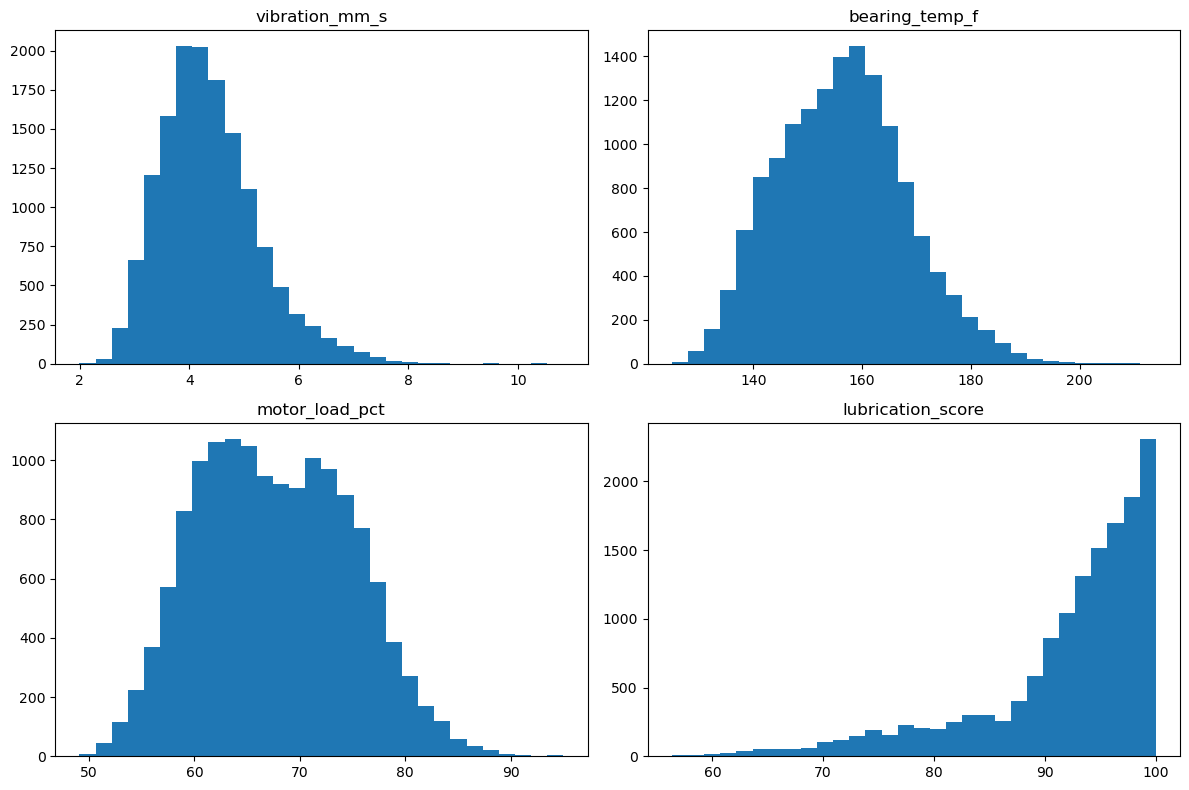

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
cols = ["vibration_mm_s", "bearing_temp_f", "motor_load_pct", "lubrication_score"]
for ax, col in zip(axes, cols):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 6. Time-based train/test split

In [8]:
def temporal_split(dataframe, test_days=45):
    cutoff = dataframe["timestamp"].max() - pd.Timedelta(days=test_days)
    return dataframe[dataframe["timestamp"] <= cutoff].copy(), dataframe[dataframe["timestamp"] > cutoff].copy()

train_df, test_df = temporal_split(df, test_days=45)
print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Train max date:", train_df["timestamp"].max())
print("Test min date:", test_df["timestamp"].min())


Train: (11700, 29)
Test: (2700, 29)
Train max date: 2024-07-13 00:00:00
Test min date: 2024-07-14 00:00:00


## 7. Preprocessing pipeline

In [9]:
categorical_cols = [c for c in FEATURES if df[c].dtype == "object"]
numeric_cols = [c for c in FEATURES if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols),
    ]
)

categorical_cols, numeric_cols[:10]


(['machine_type', 'shift', 'duty_class'],
 ['machine_age_years',
  'ambient_temp_f',
  'humidity_pct',
  'operating_hours',
  'days_since_maintenance',
  'tool_wear_hours',
  'rpm',
  'motor_load_pct',
  'voltage_v',
  'hydraulic_pressure_psi'])

## 8. Train multi-horizon failure models

In [10]:
def optimize_threshold(y_true, prob):
    best_threshold = 0.50
    best_score = -1.0
    best_pred = (prob >= best_threshold).astype(int)
    for threshold in np.arange(0.10, 0.86, 0.05):
        pred = (prob >= threshold).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_score:
            best_score = score
            best_threshold = float(threshold)
            best_pred = pred
    return best_threshold, best_pred

def build_models(preprocessor):
    return {
        "Logistic Regression": Pipeline([
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=1200, class_weight="balanced"))
        ]),
        "Decision Tree": Pipeline([
            ("preprocessor", preprocessor),
            ("model", DecisionTreeClassifier(max_depth=6, min_samples_leaf=18, class_weight="balanced", random_state=42))
        ]),
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(n_estimators=180, max_depth=10, min_samples_leaf=8, class_weight="balanced_subsample", random_state=42, n_jobs=-1))
        ]),
        "Gradient Boosting": Pipeline([
            ("preprocessor", preprocessor),
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
    }

results = []
trained_models = {}
X_train = train_df[FEATURES]
X_test = test_df[FEATURES]

for horizon, target in TARGETS.items():
    trained_models[horizon] = {}
    for model_name, model in build_models(preprocessor).items():
        model.fit(X_train, train_df[target])
        prob = model.predict_proba(X_test)[:, 1]
        threshold, pred = optimize_threshold(test_df[target], prob)
        results.append({
            "Horizon": horizon,
            "Model": model_name,
            "Accuracy": accuracy_score(test_df[target], pred),
            "Precision": precision_score(test_df[target], pred, zero_division=0),
            "Recall": recall_score(test_df[target], pred, zero_division=0),
            "F1 Score": f1_score(test_df[target], pred, zero_division=0),
            "ROC AUC": roc_auc_score(test_df[target], prob) if test_df[target].nunique() > 1 else np.nan,
            "PR AUC": average_precision_score(test_df[target], prob),
            "Threshold": threshold,
        })
        trained_models[horizon][model_name] = model

results_df = pd.DataFrame(results).sort_values(["Horizon", "F1 Score"], ascending=[True, False])
results_df


,Horizon,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Threshold
6,Next 30 Days,Random Forest,0.766667,0.659218,0.802721,0.723926,0.848088,0.765584,0.60
5,Next 30 Days,Decision Tree,0.743333,0.615385,0.870748,0.721127,0.815969,0.674442,0.45
7,Next 30 Days,Gradient Boosting,0.752963,0.633678,0.833819,0.720101,0.843557,0.746633,0.55
4,Next 30 Days,Logistic Regression,0.749630,0.634221,0.810496,0.711604,0.808042,0.668913,0.50
3,Next 7 Days,Gradient Boosting,0.819259,0.421462,0.700258,0.526214,0.867051,0.549182,0.25
0,Next 7 Days,Logistic Regression,0.832963,0.440741,0.614987,0.513484,0.847898,0.458404,0.70
2,Next 7 Days,Random Forest,0.793704,0.384196,0.728682,0.503122,0.859919,0.544893,0.55
1,Next 7 Days,Decision Tree,0.754074,0.344905,0.795866,0.481250,0.829398,0.475554,0.65
10,Next 90 Days,Random Forest,0.686667,0.580860,0.861635,0.693922,0.799567,0.696570,0.85
8,Next 90 Days,Logistic Regression,0.652963,0.554658,0.802336,0.655894,0.755302,0.715580,0.60


## 9. Visualize model comparison

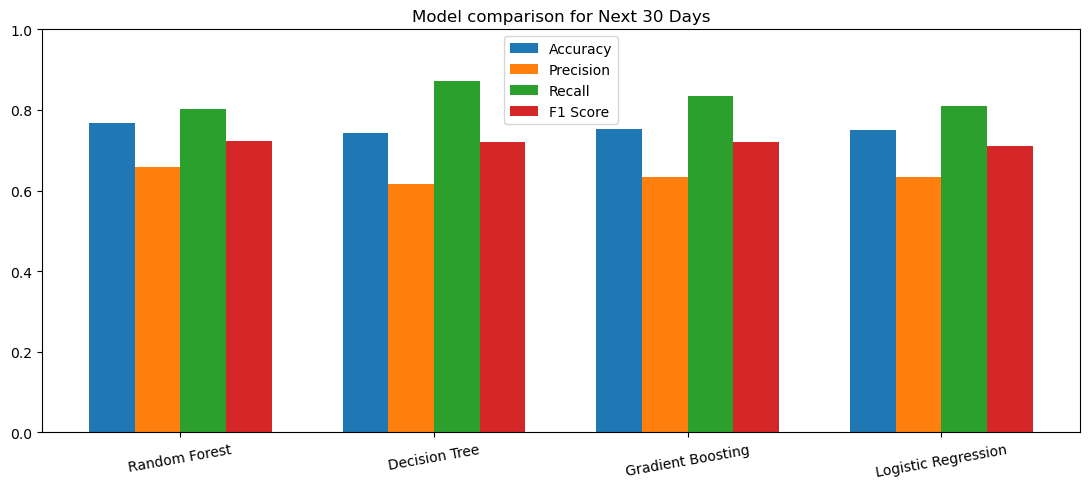

In [11]:
selected_horizon = "Next 30 Days"
plot_df = results_df[results_df["Horizon"] == selected_horizon].copy()
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(plot_df))
width = 0.18
fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + (i - 1.5) * width, plot_df[metric].values, width=width, label=metric)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"], rotation=10)
ax.set_ylim(0, 1)
ax.set_title(f"Model comparison for {selected_horizon}")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Confusion matrix for best 30-day model

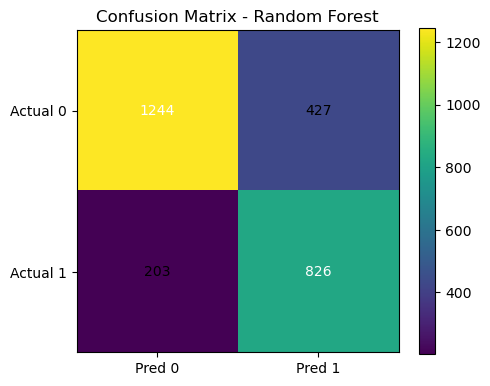

In [12]:
best_30 = plot_df.sort_values("F1 Score", ascending=False).iloc[0]
best_30_model_name = best_30["Model"]
best_30_model = trained_models["Next 30 Days"][best_30_model_name]
prob_30 = best_30_model.predict_proba(X_test)[:, 1]
thr_30, pred_30 = optimize_threshold(test_df[TARGETS["Next 30 Days"]], prob_30)
cm = confusion_matrix(test_df[TARGETS["Next 30 Days"]], pred_30)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], ["Actual 0", "Actual 1"])
ax.set_title(f"Confusion Matrix - {best_30_model_name}")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 11. Feature importance review

In [13]:
pipe = best_30_model
pre = pipe.named_steps["preprocessor"]
model = pipe.named_steps["model"]
names = pre.get_feature_names_out()
if hasattr(model, "feature_importances_"):
    scores = model.feature_importances_
else:
    scores = np.abs(model.coef_[0])

feat_df = pd.DataFrame({"Feature": names, "Score": scores})
feat_df["Feature"] = feat_df["Feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)
feat_df = feat_df.sort_values("Score", ascending=False).head(15)
feat_df


,Feature,Score
4,days_since_maintenance,0.183367
11,vibration_mm_s,0.157157
10,lubrication_score,0.098964
12,bearing_temp_f,0.079881
13,dust_collector_dp_inwc,0.078388
14,servo_current_a,0.063461
3,operating_hours,0.042346
5,tool_wear_hours,0.040526
7,motor_load_pct,0.034357
15,vacuum_pressure_kpa,0.031025


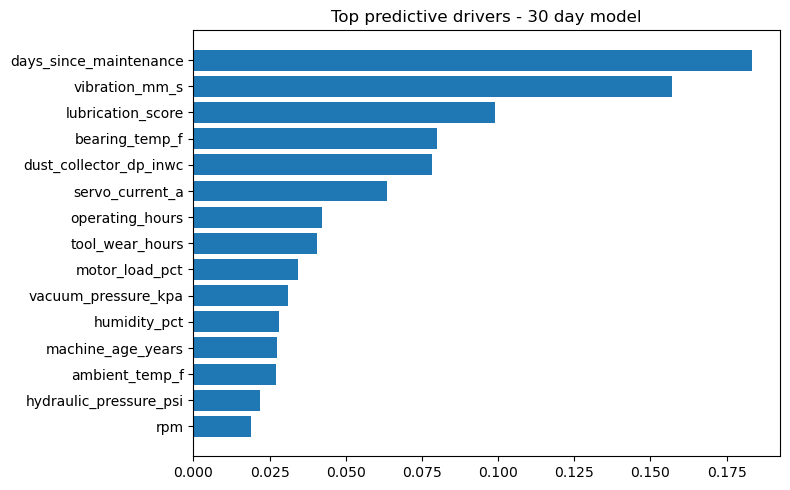

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_df["Feature"][::-1], feat_df["Score"][::-1])
ax.set_title("Top predictive drivers - 30 day model")
plt.tight_layout()
plt.show()


## 12. Anomaly detection

In [15]:
numeric_for_anomaly = [c for c in FEATURES if df[c].dtype != "object"]
anomaly_X = df[numeric_for_anomaly].copy().fillna(df[numeric_for_anomaly].median(numeric_only=True))
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
anomaly_pred = iso.fit_predict(anomaly_X)
anomaly_score = -iso.score_samples(anomaly_X)

df_anom = df[["timestamp", "machine_id"] + numeric_for_anomaly].copy()
df_anom["anomaly_score"] = anomaly_score
df_anom["anomaly_flag"] = (anomaly_pred == -1).astype(int)
df_anom[["anomaly_score", "anomaly_flag"]].head()


,anomaly_score,anomaly_flag
0,0.495032,0
1,0.495531,0
2,0.481312,0
3,0.495154,0
4,0.488409,0


In [16]:
latest_snapshot = df.sort_values("timestamp").groupby("machine_id").tail(1).copy()
latest_anom = df_anom.loc[latest_snapshot.index, ["anomaly_score", "anomaly_flag"]].copy()
latest_snapshot = latest_snapshot.join(latest_anom)
latest_snapshot[["machine_id", "anomaly_score", "anomaly_flag"]].sort_values("anomaly_score", ascending=False).head(15)


,machine_id,anomaly_score,anomaly_flag
5279,MCH-022,0.576544,1
2159,MCH-009,0.565713,1
8399,MCH-035,0.530314,0
5519,MCH-023,0.527110,0
4799,MCH-020,0.521106,0
5999,MCH-025,0.520122,0
6959,MCH-029,0.517903,0
9119,MCH-038,0.507164,0
1679,MCH-007,0.503433,0
9839,MCH-041,0.502367,0


## 13. Fleet health and risk scoring

In [17]:
def normalize(series, invert=False):
    s = pd.Series(series).astype(float)
    if s.max() == s.min():
        out = pd.Series(np.full(len(s), 50.0), index=s.index)
    else:
        out = (s - s.min()) / (s.max() - s.min()) * 100.0
    if invert:
        out = 100 - out
    return out.clip(0, 100)

latest_rows = df.sort_values("timestamp").groupby("machine_id").tail(1).copy()
latest_rows["risk_30d"] = best_30_model.predict_proba(latest_rows[FEATURES])[:, 1]
latest_rows["risk_7d"] = np.clip(latest_rows["risk_30d"] * 0.68, 0.01, 0.99)
latest_rows["risk_90d"] = np.clip(latest_rows["risk_30d"] * 1.23, 0.01, 0.99)

def health_score(frame):
    vib = normalize(frame["vibration_mm_s"], invert=True)
    temp = normalize(frame["bearing_temp_f"], invert=True)
    load = normalize(frame["motor_load_pct"], invert=True)
    servo = normalize(frame["servo_current_a"], invert=True)
    dust = normalize(frame["dust_collector_dp_inwc"], invert=True)
    lube = normalize(frame["lubrication_score"], invert=False)
    return (0.22*vib + 0.22*temp + 0.16*load + 0.14*servo + 0.12*dust + 0.14*lube).clip(0, 100)

latest_rows["health_score"] = health_score(latest_rows)
latest_rows[["machine_id", "risk_30d", "health_score"]].sort_values("risk_30d", ascending=False).head(15)


,machine_id,risk_30d,health_score
2159,MCH-009,0.926329,23.739904
2879,MCH-012,0.922049,36.275089
8159,MCH-034,0.919256,48.689960
6239,MCH-026,0.859804,40.822415
11039,MCH-046,0.857640,51.128978
13679,MCH-057,0.848434,44.944953
9839,MCH-041,0.848365,34.055625
5279,MCH-022,0.845024,9.120296
2639,MCH-011,0.824524,50.317964
12719,MCH-053,0.819341,36.515206


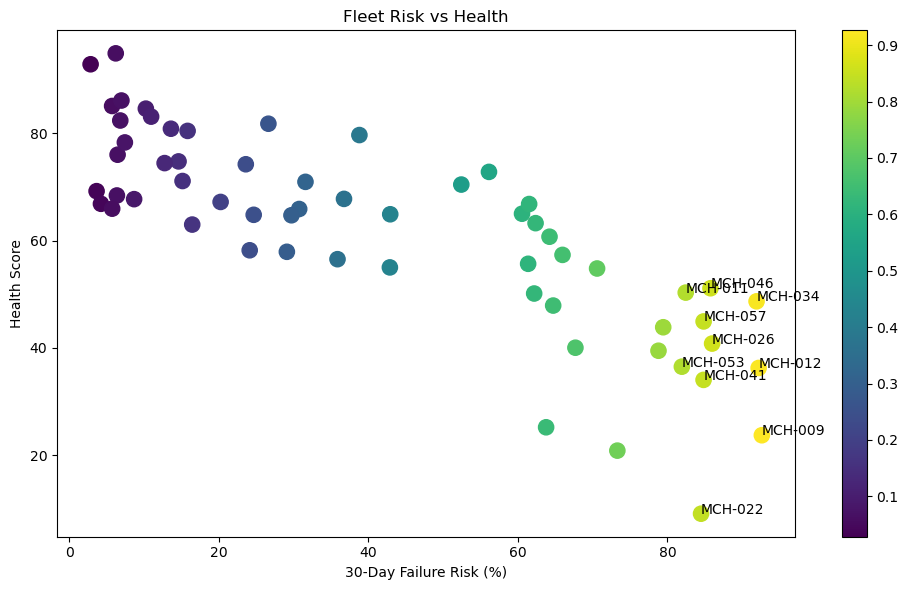

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(latest_rows["risk_30d"]*100, latest_rows["health_score"], c=latest_rows["risk_30d"], s=120)
top = latest_rows.sort_values("risk_30d", ascending=False).head(10)
for _, row in top.iterrows():
    ax.annotate(row["machine_id"], (row["risk_30d"]*100, row["health_score"]))
ax.set_xlabel("30-Day Failure Risk (%)")
ax.set_ylabel("Health Score")
ax.set_title("Fleet Risk vs Health")
plt.colorbar(sc, ax=ax)
plt.tight_layout()
plt.show()


## 14. Save advanced artifacts

In [20]:
import joblib
import json
import pandas as pd
import os
from pathlib import Path

# Define the MODELS_DIR variable before using it
MODELS_DIR = Path("./models")  # Replace with your desired directory path
# Alternatively, you could use: MODELS_DIR = os.path.join(".", "models")

# Create the directory if it doesn't exist
MODELS_DIR.mkdir(exist_ok=True)

# Now the rest of your code will work
joblib.dump(best_30_model, MODELS_DIR / "advanced_failure_30d_gb.joblib")
df_anom[["timestamp", "machine_id", "anomaly_score", "anomaly_flag"]].to_csv(MODELS_DIR / "advanced_anomaly_scores.csv", index=False)
summary = {
    "dataset_rows": int(len(df)),
    "machines": int(df["machine_id"].nunique()),
    "failure_model": {
        "best_model_30d": best_30_model_name,
        "roc_auc": None if pd.isna(best_30["ROC AUC"]) else float(best_30["ROC AUC"]),
        "pr_auc": float(best_30["PR AUC"]),
        "threshold": float(best_30["Threshold"]),
    },
    "anomaly_model": {
        "rows_scored": int(len(df_anom)),
        "anomaly_flags": int(df_anom["anomaly_flag"].sum()),
    }
}
with open(MODELS_DIR / "advanced_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary


{'dataset_rows': 14400,
 'machines': 60,
 'failure_model': {'best_model_30d': 'Random Forest',
  'roc_auc': 0.8480882649717149,
  'pr_auc': 0.7655839400028237,
  'threshold': 0.6000000000000002},
 'anomaly_model': {'rows_scored': 14400, 'anomaly_flags': 720}}

## 15. Next recommended steps

1. Run the Streamlit dashboards using the saved artifacts.
2. Add SHAP explainability with the advanced model.
3. Add LSTM sequence learning once TensorFlow is installed and stable.
4. Extend the control room dashboard to a fleet wallboard with top alerts and anomaly ranking.
